In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np
from astropy.cosmology import LambdaCDM

import time
import emcee
from multiprocessing import Pool

from planck_lite import PlanckLitePy

In [ ]:
file = 'data/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt'

df = pd.read_csv(file, sep='\s+')
df

ellmin=int(df['L'][0])

,L,TT,TE,EE,BB,PP
0,2,1016.7300,2.61753,0.030883,0.000002,5.013520e-08
1,3,963.7270,2.93806,0.039690,0.000004,6.099430e-08
2,4,912.6080,2.75866,0.034496,0.000006,7.025920e-08
3,5,874.4770,2.35185,0.023094,0.000009,7.829210e-08
4,6,848.5090,1.89605,0.012951,0.000013,8.530200e-08
...,...,...,...,...,...,...
2502,2504,77.6127,-2.96537,2.910040,0.000000,0.000000e+00
2503,2505,77.3908,-2.97153,2.913030,0.000000,0.000000e+00
2504,2506,77.1691,-2.97827,2.916090,0.000000,0.000000e+00
2505,2507,76.9485,-2.98537,2.919000,0.000000,0.000000e+00


# MCMC

In [ ]:
def ln_prior(params):
    H_0, Om_m, Om_l = params
    if H_0 < 0:
        return -np.inf
    elif Om_m < 0 or Om_m > 1:
        return -np.inf
    elif Om_l < 0 or Om_l > 1:
        return -np.inf
    else:
        return 0
 
TT2018=PlanckLitePy(data_directory='data', year=2018, spectra='TT', use_low_ell_bins=False)
def ln_likelihood(params, data_df):
    

def ln_pdf(params):
    p = ln_prior(params)
    if p == -np.inf:
        return -np.inf
    return p + ln_likelihood(params, pd.concat((low_z, high_z)))

In [416]:
n_dim, n_walkers = 3, 16
n_iterations = 5000
p0 = np.random.multivariate_normal(mean=[73, 0.3, 0.7], cov=np.diag([1, 1e-12, 1e-12]), size=n_walkers)

print([ln_prior(x) for x in p0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [417]:
with Pool() as pool:
    start = time.time()
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, ln_pdf, pool=pool)
    sampler.run_mcmc(p0, n_iterations, progress=True)
    dur = time.time() - start
    print(f'MCMC took {dur:.3f} seconds')

100%|██████████| 5000/5000 [01:08<00:00, 73.01it/s]


MCMC took 68.508 seconds


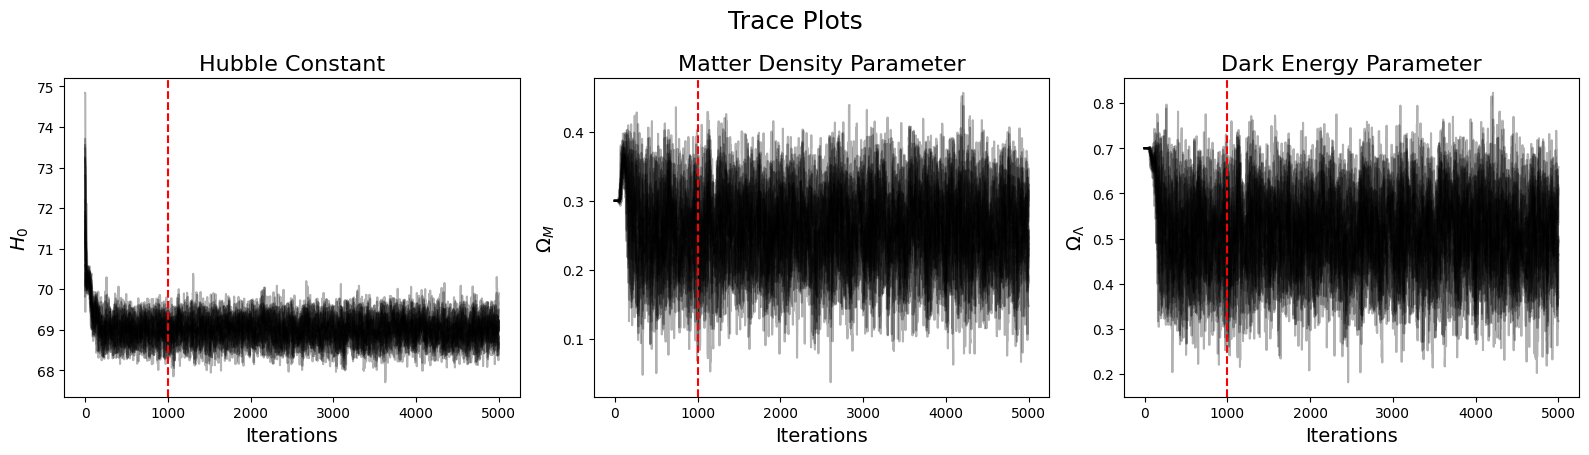

In [418]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'Dark Energy Parameter']
y_labels = [r'$H_0$', r'$\Omega_M$', r'$\Omega_\Lambda$']
for i in range(0, 3):
    axs[i].plot(sampler.get_chain()[:,:,i], 'k', alpha=0.3)
    axs[i].set_xlabel('Iterations', size=14)
    axs[i].set_title(titles[i], size=16)
    axs[i].set_ylabel(y_labels[i], size=14)
    axs[i].axvline(x=1000, color='red', linestyle='dashed')

fig.suptitle('Trace Plots', size=18)
plt.tight_layout()
plt.show()

In [419]:
burned = pd.DataFrame(sampler.get_chain(discard=1000, flat=True), columns=['H_0', 'Om_m', 'Om_l'])
burned['Om_k'] = 1.0 - burned['Om_m'] - burned['Om_l']
burned = burned.sort_values(by='Om_m')

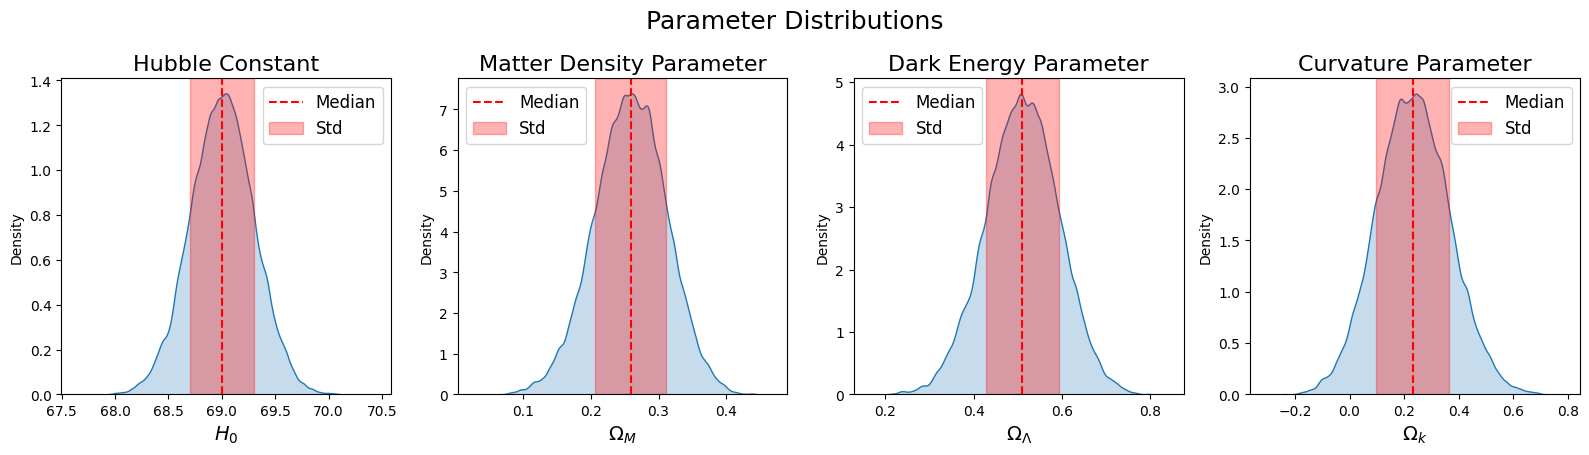

In [420]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'Dark Energy Parameter', 'Curvature Parameter']
x_labels = [r'$H_0$', r'$\Omega_M$', r'$\Omega_\Lambda$', r'$\Omega_k$']
for i in range(0, 4):
    sns.kdeplot(burned.iloc[:,i], fill=True, ax=axs[i], bw_adjust=0.7)
    axs[i].set_xlabel(x_labels[i], size=14)
    axs[i].set_title(titles[i], size=16)
    median = np.median(burned.iloc[:,i])
    std = np.std(burned.iloc[:,i])
    axs[i].axvline(median, color='red', linestyle='dashed', label='Median')
    axs[i].axvspan(median-std, median+std, color='red', alpha=0.3, label='Std')
    axs[i].legend(fontsize=12)

fig.suptitle('Parameter Distributions', size=18)
plt.tight_layout()
plt.show()

In [421]:
print(f'H_0  = {np.median(burned.iloc[:,0]):.2f} ± {np.std(burned.iloc[:,0]):.2f} km / s / Mpc')
print(f'Om_m = {np.median(burned.iloc[:,1]):.2f} ± {np.std(burned.iloc[:,1]):.2f}')
print(f'Om_l = {np.median(burned.iloc[:,2]):.2f} ± {np.std(burned.iloc[:,2]):.2f}')
print(f'Om_k = {np.median(burned.iloc[:,3]):.2f} ± {np.std(burned.iloc[:,3]):.2f}')

H_0  = 69.00 ± 0.30 km / s / Mpc
Om_m = 0.26 ± 0.05
Om_l = 0.51 ± 0.08
Om_k = 0.23 ± 0.13


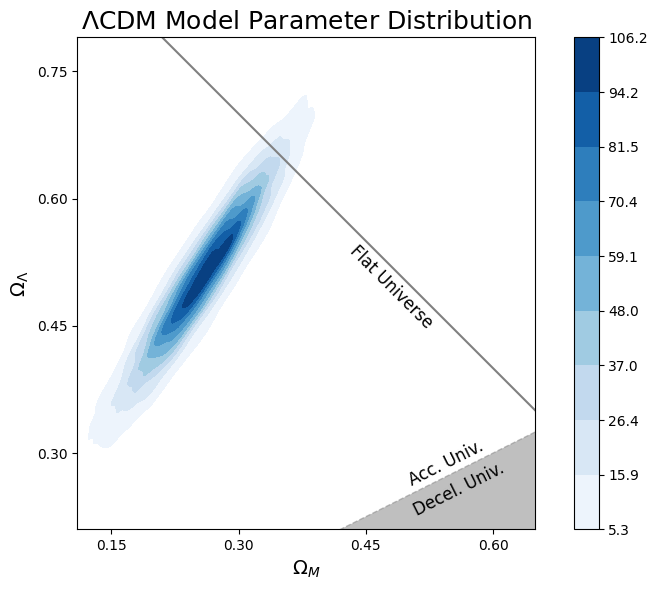

In [423]:
fig, ax = plt.subplots(figsize=(8,6))
ax.set_aspect('equal')

sns.kdeplot(x=burned['Om_m'], y=burned['Om_l'], cmap='Blues', fill=True, cbar=True)

X = np.linspace(0, 1, 100)
plt.plot(X, 1 - X, color='gray')
plt.fill_between(X, 0.5*X, color='gray', alpha=0.5, linestyle='dashed')

rotn = np.degrees(np.arctan2(1, 2))
plt.annotate('Acc. Univ.', xy=(0.545, 0.2875), ha='center', va='center', rotation=rotn, fontsize=12)
plt.annotate('Decel. Univ.', xy=(0.56, 0.2575), ha='center', va='center', rotation=rotn, fontsize=12)

rotn = np.degrees(np.arctan2(X[0]-X[1], X[1]-X[0]))
plt.annotate('Flat Universe', xy=(0.48, 0.495), ha='center', va='center', rotation=rotn, fontsize=12)

plt.xlabel('$\Omega_M$', size=14)
plt.ylabel('$\Omega_\Lambda$', size=14)
plt.xlim(0.11, 0.65)
plt.ylim(0.21, 0.79)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.15))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.15))
plt.title('$\Lambda$CDM Model Parameter Distribution', size=18)
plt.tight_layout()
plt.show()